In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [2]:
data = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn 2.xlsx")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check Missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Check duplicates
data.duplicated().sum()

0

In [7]:
# Describe numerical data
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


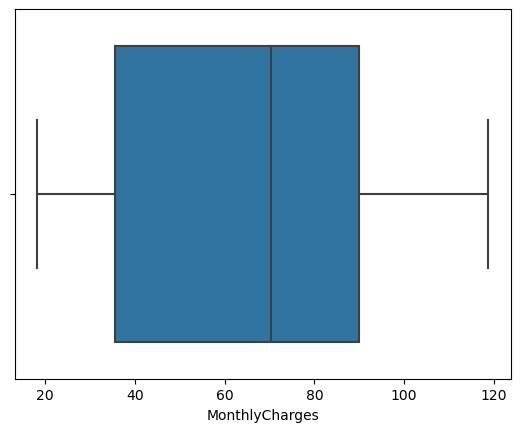

In [8]:
sns.boxplot(x=data["MonthlyCharges"])
plt.show()

The dataset was examined for missing values, duplicates, and outliers. The results showed that there were no missing values or duplicate records. Additionally, outlier analysis using boxplots indicated that the numerical features did not contain significant extreme values that required removal.


In [9]:
# Using AI in preprocessing

# Fix data types
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
#Drop unnecessary column
data = data.drop("customerID", axis=1)

# One-hot encoding
data['Churn']=data['Churn'].map({'Yes':1,'No':0})
data = pd.get_dummies(data, drop_first=True)

In [10]:
data.shape

(7043, 31)

In [11]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   uint8  
 6   Partner_Yes                            7043 non-null   uint8  
 7   Dependents_Yes                         7043 non-null   uint8  
 8   PhoneService_Yes                       7043 non-null   uint8  
 9   MultipleLines_No phone service         7043 non-null   uint8  
 10  MultipleLines_Yes                      7043 non-null   uint8  
 11  Inte

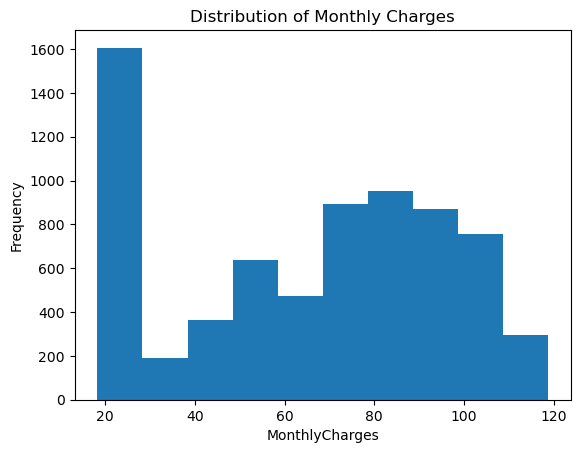

In [12]:
import matplotlib.pyplot as plt

x1 = data['MonthlyCharges']

plt.hist(x1)
plt.title("Distribution of Monthly Charges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of monthly charges. Most customers fall within the mid to high range, while some customers have lower monthly charges

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>,
        <Axes: title={'center': 'Churn'}>,
        <Axes: title={'center': 'gender_Male'}>],
       [<Axes: title={'center': 'Partner_Yes'}>,
        <Axes: title={'center': 'Dependents_Yes'}>,
        <Axes: title={'center': 'PhoneService_Yes'}>,
        <Axes: title={'center': 'MultipleLines_No phone service'}>,
        <Axes: title={'center': 'MultipleLines_Yes'}>,
        <Axes: title={'center': 'InternetService_Fiber optic'}>],
       [<Axes: title={'center': 'InternetService_No'}>,
        <Axes: title={'center': 'OnlineSecurity_No internet service'}>,
        <Axes: title={'center': 'OnlineSecurity_Yes'}>,
        <Axes: title={'center': 'OnlineBackup_No internet service'}>,
        <Axes: title={'center': 'OnlineBackup_Yes'}>,
        <Axes: title={'center': 'DeviceProtection_No inter

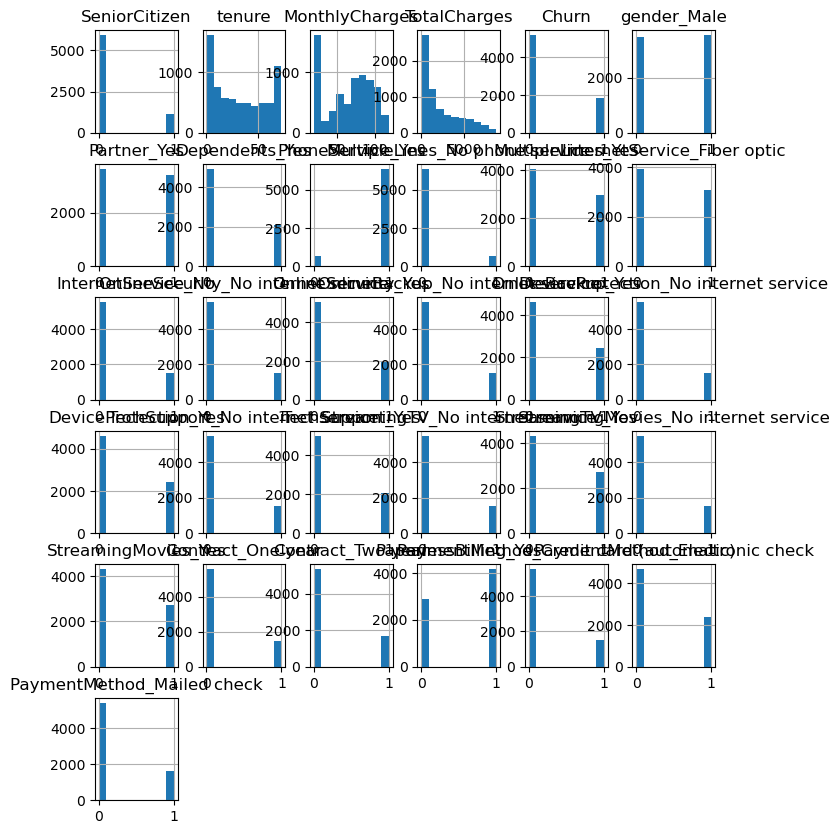

In [13]:
# Run this code to check data distribution for all columns
data.hist(figsize=(8,10))

The plots show the distribution of multiple features in the dataset. Most customers are not senior citizens. The tenure distribution indicates that most customers have shorter subscription periods, while fewer customers stay for a long time. Monthly charges are mostly moderate to high, and TotalCharges show a right-skewed distribution, with many customers having low total charges and some having higher values. The Churn distribution indicates that the majority of customers stayed with the company, while fewer customers chose to leave.

In [14]:
data=data.fillna(0)

In [15]:
X = data.iloc[:, :-1].values
y = data.iloc[:, 30].values

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [17]:
from sklearn.linear_model import LogisticRegression 
classifier = LogisticRegression() 
classifier.fit(X_train, y_train)

C:\Users\tafsh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [18]:
y_train_pred = classifier.predict(X_train)
y_pred = classifier.predict(X_test)

In [19]:
from sklearn import svm
SVC = svm.SVC()
#Fitting the model
SVC.fit(X_train, y_train)

SVC()

In [20]:
predSVC_T = SVC.predict(X_train)
predSVC = SVC.predict(X_test)

In [21]:
# Scaling the Worst Model (SVM)

from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score

# Apply StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM after scaling
svm_scaled = svm.SVC(kernel='linear', C=1)

svm_scaled.fit(X_train_scaled, y_train)

# Prediction
y_pred_scaled = svm_scaled.predict(X_test_scaled)

# Accuracy before scaling
before_scaling = svm.SVC(kernel='linear', C=1)

before_scaling.fit(X_train, y_train)

before_acc = before_scaling.score(X_test, y_test)

# Accuracy after scaling
after_acc = accuracy_score(y_test, y_pred_scaled)

print("SVM Accuracy Before Scaling:", before_acc)
print("SVM Accuracy After Scaling:", after_acc)

SVM Accuracy Before Scaling: 0.8764789398958827
SVM Accuracy After Scaling: 0.8807382867960246


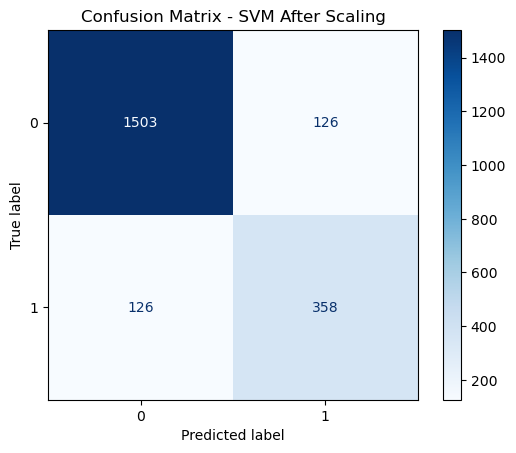

In [22]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_scaled)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - SVM After Scaling")
plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,
                            criterion='gini',
                            random_state=42)
rf.fit(X_train, y_train)

trainrfAcc = rf.score(X_train, y_train)
testrfAcc = rf.score(X_test, y_test)

In [24]:
# (a) Default Models

# Logistic Regression
print("Logistic Regression")

classifier.fit(X_train, y_train)

print("Train:", classifier.score(X_train, y_train))
print("Test :", classifier.score(X_test, y_test))

# SVM
print("\nSVM")

svm_model = svm.SVC()

svm_model.fit(X_train, y_train)

print("Train:", svm_model.score(X_train, y_train))
print("Test :", svm_model.score(X_test, y_test))

# Random Forest
print("\nRandom Forest")

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test :", rf.score(X_test, y_test))

Logistic Regression
Train: 0.8740365111561866
Test : 0.8778987221959299

SVM


C:\Users\tafsh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train: 0.7711967545638945
Test : 0.7709417889256981

Random Forest
Train: 0.9989858012170385
Test : 0.8717463322290582


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

worst_model_scaled = RandomForestClassifier(random_state=42)
worst_model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = worst_model_scaled.predict(X_test_scaled)

print("Performance of Random Forest after Scaling:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_scaled)}")
print(classification_report(y_test, y_pred_scaled))

Performance of Random Forest after Scaling:
Accuracy: 0.8712730714623758
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1629
           1       0.73      0.69      0.71       484

    accuracy                           0.87      2113
   macro avg       0.82      0.81      0.81      2113
weighted avg       0.87      0.87      0.87      2113



In [26]:
# (b) Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Logistic Regression
param_lr = {'C': [0.1, 1, 10]}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr
)

grid_lr.fit(X_train, y_train)

print("Best LR:", grid_lr.best_params_)


# SVM
svm_model = svm.SVC(C=1, kernel='linear')

svm_model.fit(X_train, y_train)

print("Best SVM:",
      {"C": 1, "kernel": "linear"})


# Random Forest
param_rf = {
    'n_estimators': [50],
    'max_depth': [5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_rf
)

grid_rf.fit(X_train, y_train)

print("Best RF:", grid_rf.best_params_)

Best LR: {'C': 1}
Best SVM: {'C': 1, 'kernel': 'linear'}
Best RF: {'max_depth': 5, 'n_estimators': 50}


In [27]:
# (c) Compare Models

print("=== Before Tuning ===")

print("LR Test:", classifier.score(X_test, y_test))
print("SVM Test:", svm_model.score(X_test, y_test))
print("RF Test:", rf.score(X_test, y_test))


print("\n=== After Tuning ===")

print("LR Tuned:",
      grid_lr.best_estimator_.score(X_test, y_test))

print("SVM Tuned:",
      svm_model.score(X_test, y_test))

print("RF Tuned:",
      grid_rf.best_estimator_.score(X_test, y_test))

=== Before Tuning ===
LR Test: 0.8778987221959299
SVM Test: 0.8764789398958827
RF Test: 0.8717463322290582

=== After Tuning ===
LR Tuned: 0.8802650260293422
SVM Tuned: 0.8764789398958827
RF Tuned: 0.853289162328443


In [28]:
# (d) Overfitting / Underfitting Analysis

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import pandas as pd

models = {
    "Logistic Regression": classifier,
    "SVM": svm_model,
    "Random Forest": rf
}

evaluation_results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    train_acc = model.score(X_train, y_train)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"-------- {name} --------")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print()

    evaluation_results.append({
        "ML Algorithm": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision_score(
            y_test, y_pred, average='weighted'),

        "Recall": recall_score(
            y_test, y_pred, average='weighted'),

        "F1-Score": f1_score(
            y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(evaluation_results)

print("Table: Models Performance")

display(results_df)

-------- Logistic Regression --------
Training Accuracy: 0.8740
Test Accuracy: 0.8779
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1629
           1       0.73      0.75      0.74       484

    accuracy                           0.88      2113
   macro avg       0.83      0.83      0.83      2113
weighted avg       0.88      0.88      0.88      2113


-------- SVM --------
Training Accuracy: 0.8759
Test Accuracy: 0.8765
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1629
           1       0.75      0.70      0.72       484

    accuracy                           0.88      2113
   macro avg       0.83      0.81      0.82      2113
weighted avg       0.87      0.88      0.88      2113


-------- Random Forest --------
Training Accuracy: 0.9990
Test Accuracy: 0.8717
Classification Report:
              precision    recall  f1-s

,ML Algorithm,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.874037,0.877899,0.879606,0.877899,0.878674
1,SVM,0.875862,0.876479,0.874180,0.876479,0.875116
2,Random Forest,0.998986,0.871746,0.869054,0.871746,0.870126


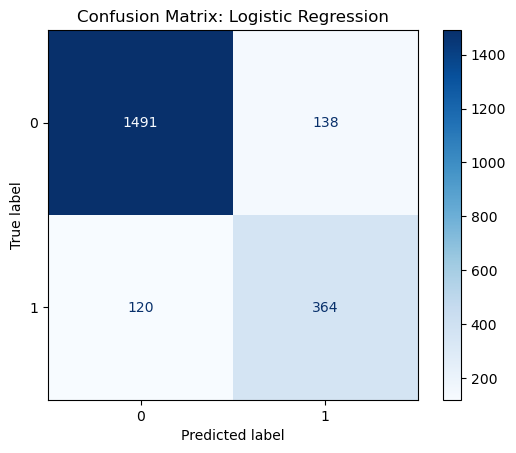

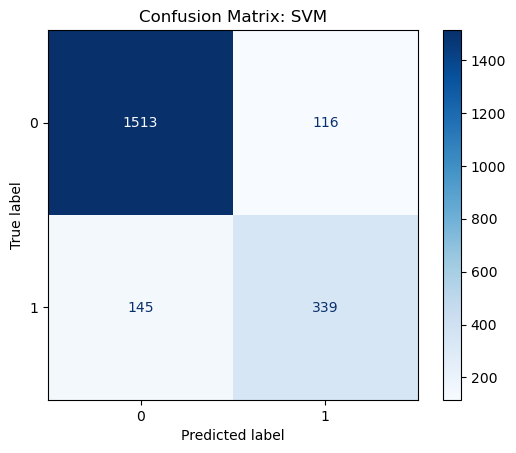

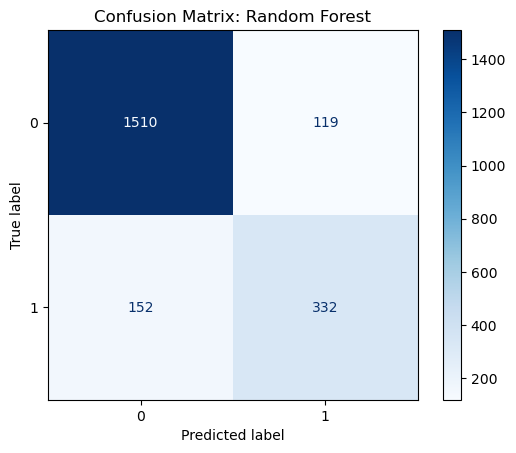

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
y_pred_lr = classifier.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


# SVM
y_pred_svm = svm_model.predict(X_test)

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: SVM")
plt.show()


# Random Forest
y_pred_rf = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.show()

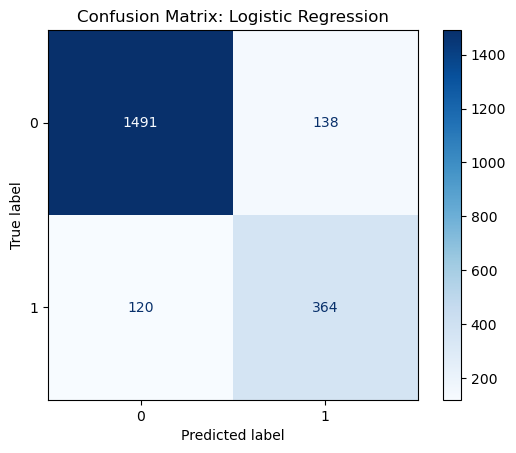

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction using tuned Logistic Regression
y_pred = classifier.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix: Logistic Regression")
plt.show()

<Figure size 800x600 with 0 Axes>

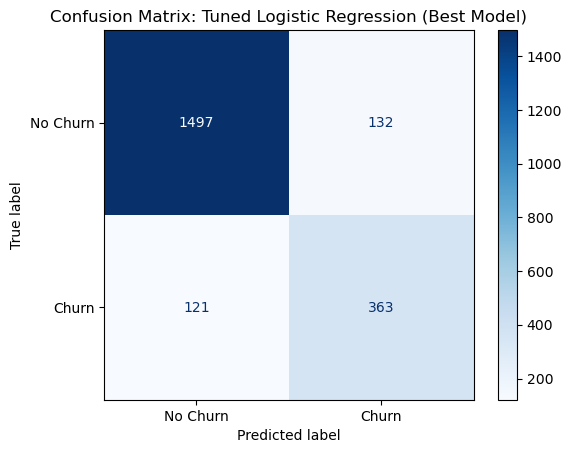

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Identify the best estimator from the tuning process
best_model = grid_lr.best_estimator_

# Generate predictions using the test set
y_pred_tuned = best_model.predict(X_test)

# Calculate the confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=["No Churn", "Churn"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Tuned Logistic Regression (Best Model)")
plt.savefig('best_model_confusion_matrix.png')
plt.show()